In [1]:
from matplotlib.colors import ListedColormap, to_rgb
import numpy as np
import matplotlib.pyplot as plt

classes = {0: "road", 1: "sidewalk", 2: "building", 3: "wall", 4: "fence", 5: "pole", 
        6: "traffic light", 7: "traffic sign", 8: "vegetation", 9: "terrain", 10: "sky", 11: "person", 
        12: "rider", 13: "car", 14: "truck", 15: "bus", 16: "train", 17: "motorcycle", 18: "bicycle", 19: "others"}
##FFFFFF
color_mapping = {
    #Flat surfaces
    "road": "#666666", "sidewalk": "#282828",
    #Construction
    "building": "#FF3232", "wall" : "#6a329f", "fence": "#FFC1C1",
    #Objects / infrastructure
    "pole": "#523415", "traffic light": "#FFFF66", "traffic sign": "#FFFF00",
    #Nature
    "vegetation": "#008000", "terrain": "#6BAF6B",
    #Sky
    "sky": "#00b1ff",
    #Humans
    "person": "#E8BEAC", "rider": "#ac95e1",
    #Vehicle
    "car": "#FFA500", "truck": "#B07A15", "bus": "#604107", "train": "#3A2908", "motorcycle": "#EDC1E6", "bicycle": "#BEDFE5",
    #other:
    "others": "#E5ACB6"
}

colors = []
for i in sorted(classes.keys()):
    class_name = classes[i]
    colors.append(to_rgb(color_mapping[class_name]))

config_cmap = ListedColormap(colors)

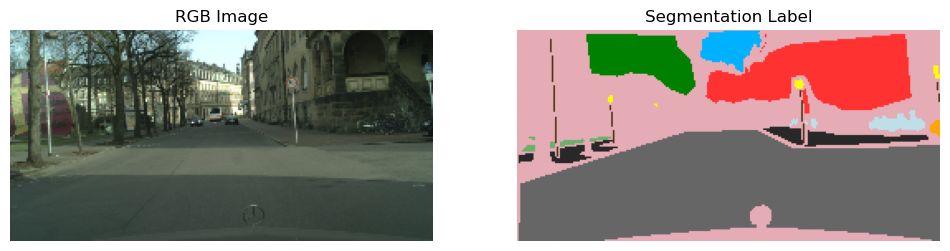

In [10]:
# Load numpy arrays
# n = 151
n = 4773#454
img = np.load(f"/users/PGS0404/atran16/Desktop/CityScapeSegmentation/Data_30k/train/image/{n}.npy")      # (H,W,3)
mask = np.load(f"/users/PGS0404/atran16/Desktop/CityScapeSegmentation/Data_30k/train/label/{n}.npy")  # (H,W)
mask  = np.where(mask == -1, 19, mask)
# Fix RGB normalization (if needed)
img = img.astype(np.float32)
if img.max() > 1.0:
    print("normalize!")
    img = img / 255.0

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("RGB Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Segmentation Label")
plt.imshow(mask, cmap=config_cmap, vmin=0, vmax=19)
plt.axis("off")
plt.axis("off")

plt.show()